In [32]:
import numpy as np
import pandas as pd

In [33]:
data = pd.read_csv('1739523823_ausapparalsales4thqrt2020\AusApparalSales4thQrt2020.csv')
data.shape
 

<>:1: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
<>:1: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
C:\Users\UTL2397\AppData\Local\Temp\ipykernel_24644\1551100592.py:1: SyntaxWarning: "\A" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\A"? A raw string is also an option.
  data = pd.read_csv('1739523823_ausapparalsales4thqrt2020\AusApparalSales4thQrt2020.csv')


(7560, 6)

In [34]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    7560 non-null   str  
 1   Time    7560 non-null   str  
 2   State   7560 non-null   str  
 3   Group   7560 non-null   str  
 4   Unit    7560 non-null   int64
 5   Sales   7560 non-null   int64
dtypes: int64(2), str(4)
memory usage: 354.5 KB


In [35]:
data.describe()


,Unit,Sales
count,7560.000000,7560.000000
mean,18.005423,45013.558201
std,12.901403,32253.506944
min,2.000000,5000.000000
25%,8.000000,20000.000000
50%,14.000000,35000.000000
75%,26.000000,65000.000000
max,65.000000,162500.000000


In [36]:
data.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


In [37]:
# sales data is missing checking for missing values
data.isnull()
# data['Sales'].isnull()

,Date,Time,State,Group,Unit,Sales
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
7555,False,False,False,False,False,False
7556,False,False,False,False,False,False
7557,False,False,False,False,False,False
7558,False,False,False,False,False,False


In [38]:
# check incurect data types
data.dtypes

Date       str
Time       str
State      str
Group      str
Unit     int64
Sales    int64
dtype: object

In [39]:
# check sailse are not nigative values
data[data['Sales'] < 0]

,Date,Time,State,Group,Unit,Sales


In [40]:
# get all catagorical in Group columns
data['Group'].unique()


<StringArray>
[' Kids', ' Men', ' Women', ' Seniors']
Length: 4, dtype: str

In [41]:
# Clean incorrect values: Group/State/Time have leading/trailing whitespace (e.g. ' Kids', ' WA')
for col in ['Group', 'State', 'Time']:
    data[col] = data[col].str.strip()

# drop exact duplicate rows if any
data = data.drop_duplicates()

print(data['Group'].unique())
print(data['State'].unique())
print(data.shape)

<StringArray>
['Kids', 'Men', 'Women', 'Seniors']
Length: 4, dtype: str
<StringArray>
['WA', 'NT', 'SA', 'VIC', 'QLD', 'NSW', 'TAS']
Length: 7, dtype: str
(7560, 6)


In [42]:
# Normalize Data: min-max scale Unit and Sales into [0, 1] for comparability
data['Unit_normalized'] = (data['Unit'] - data['Unit'].min()) / (data['Unit'].max() - data['Unit'].min())
data['Sales_normalized'] = (data['Sales'] - data['Sales'].min()) / (data['Sales'].max() - data['Sales'].min())
data[['Unit', 'Unit_normalized', 'Sales', 'Sales_normalized']].head()

,Unit,Unit_normalized,Sales,Sales_normalized
0,8,0.095238,20000,0.095238
1,8,0.095238,20000,0.095238
2,4,0.031746,10000,0.031746
3,15,0.206349,37500,0.206349
4,3,0.015873,7500,0.015873


In [43]:
data['Sales'].describe()

count      7560.000000
mean      45013.558201
std       32253.506944
min        5000.000000
25%       20000.000000
50%       35000.000000
75%       65000.000000
max      162500.000000
Name: Sales, dtype: float64

In [44]:
# groups wise sales data 
data.groupby('Group')['Sales'].sum()

Group
Kids       85072500
Men        85750000
Seniors    84037500
Women      85442500
Name: Sales, dtype: int64

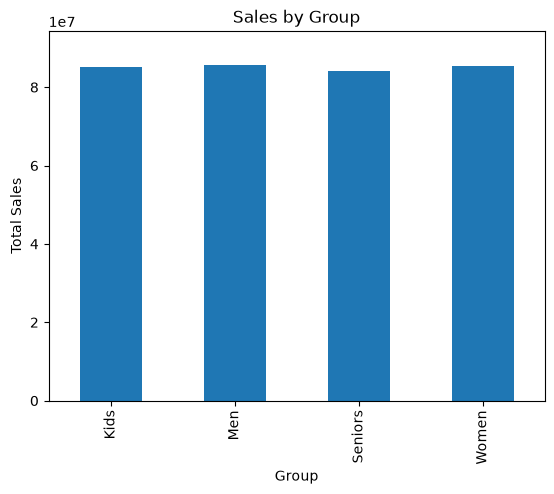

In [45]:
# show the graph of sales data and group wise and add range of sales data in y axis using matplotlib library
import matplotlib.pyplot as plt

data.groupby('Group')['Sales'].sum().plot(kind='bar')
plt.xlabel('Group')
plt.ylabel('Total Sales')
plt.title('Sales by Group')
plt.ylim(0, data.groupby('Group')['Sales'].sum().max() * 1.1)  # Set y-axis range
plt.show()


In [46]:
# highest sales groups
highest_sales_groups = data.groupby('Group')['Sales'].sum().sort_values(ascending=False)
print(highest_sales_groups)

Group
Men        85750000
Women      85442500
Kids       85072500
Seniors    84037500
Name: Sales, dtype: int64


Text(0.5, 1.0, 'Highest Sales by Group')

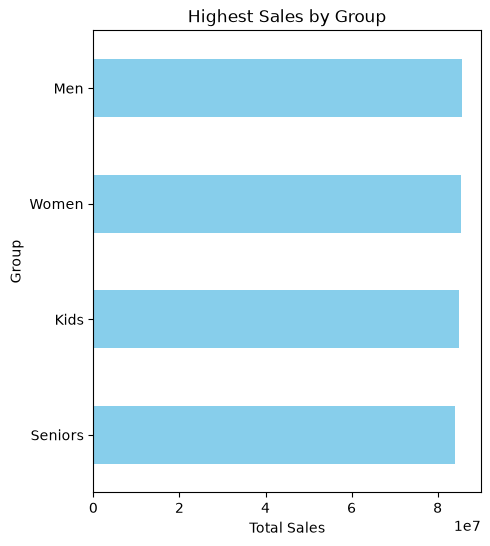

In [47]:
# highest sales groups with graph
highest_sales_groups = data.groupby('Group')['Sales'].sum().sort_values(ascending=True).head(5000)
highest_sales_groups.plot(kind='barh', figsize=(5, 6), color='skyblue')
plt.xlabel('Total Sales')
plt.ylabel('Group')
plt.title('Highest Sales by Group') 

In [48]:
# Descriptive Statistics
# anylis sales and Units columes find mean, median, mode, standard deviation, variance, skewness and kurtosis
meansInsales = data['Sales'].mean()
mediansInsales = data['Sales'].median()
modesInsales = data['Sales'].mode()[0]
stdsInsales = data['Sales'].std()
varsInsales = data['Sales'].var()
skewsInsales = data['Sales'].skew()
kurtosisesInsales = data['Sales'].kurtosis()
print("Mean:", meansInsales)
print("Median:", mediansInsales)
print("Mode:", modesInsales)
print("Standard Deviation:", stdsInsales)
print("Variance:", varsInsales)
print("Skewness:", skewsInsales)
print("Kurtosis:", kurtosisesInsales)

Mean: 45013.5582010582
Median: 35000.0
Mode: 22500
Standard Deviation: 32253.506943966073
Variance: 1040288710.1844678
Skewness: 1.0855501535060816
Kurtosis: 0.6614172266616096


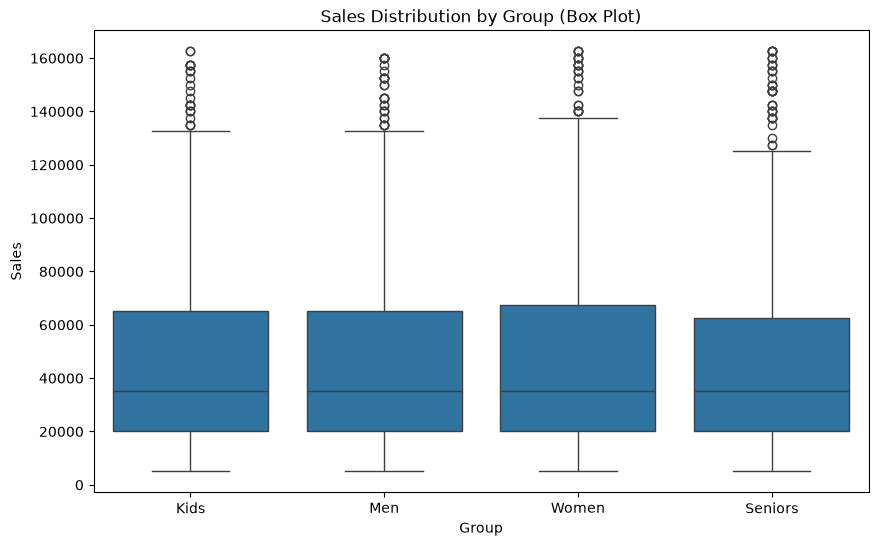

In [49]:
# Box Plot: Sales spread and outliers by Group
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=data, x='Group', y='Sales')
plt.xlabel('Group')
plt.ylabel('Sales')
plt.title('Sales Distribution by Group (Box Plot)')
plt.show()

In [3]:
if 'data' not in globals():
    import pandas as pd
    data = pd.read_csv(r'1739523823_ausapparalsales4thqrt2020\AusApparalSales4thQrt2020.csv')

group_sales = data.groupby('Group')['Sales'].sum().sort_values(ascending=False)
print("Group-wise total sales:")
print(group_sales)
print()

for grp in group_sales.index:
    grp_data = data[data['Group'] == grp]['Sales']
    q1 = grp_data.quantile(0.25)
    q3 = grp_data.quantile(0.75)
    iqr = q3 - q1
    upper = q3 + 1.5 * iqr
    outlier_count = (grp_data > upper).sum()
    print(f"{grp}: {outlier_count} outlier(s) above the upper fence ({upper:.2f})")

print()
print("Explanation:")
print("The group-wise bar chart shows how total sales are distributed across each category.")
print("If the bars are similar in height, it means no single group dominates sales.")
print("The box plot adds detail by showing the spread of sales within each group.")
print("Outliers are points beyond the whiskers, meaning those sales values are much higher than the normal range for that group.")
print("These outlier sales are worth investigating because they may indicate large one-time orders, special promotions, or potential data issues.")

Group-wise total sales:
Group
Men        85750000
Women      85442500
Kids       85072500
Seniors    84037500
Name: Sales, dtype: int64

 Men: 30 outlier(s) above the upper fence (132500.00)
 Women: 27 outlier(s) above the upper fence (138750.00)
 Kids: 25 outlier(s) above the upper fence (132500.00)
 Seniors: 39 outlier(s) above the upper fence (126250.00)

Explanation:
The group-wise bar chart shows how total sales are distributed across each category.
If the bars are similar in height, it means no single group dominates sales.
The box plot adds detail by showing the spread of sales within each group.
Outliers are points beyond the whiskers, meaning those sales values are much higher than the normal range for that group.
These outlier sales are worth investigating because they may indicate large one-time orders, special promotions, or potential data issues.


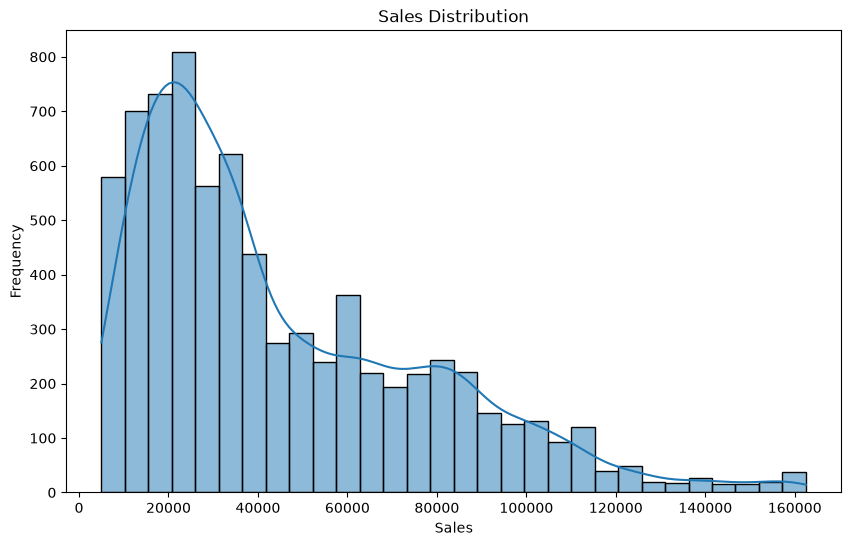

In [50]:
# Distribution Plot: overall shape of Sales values
plt.figure(figsize=(10, 6))
sns.histplot(data['Sales'], kde=True, bins=30)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Sales Distribution')
plt.show()

In [51]:
data['State'].unique()

<StringArray>
['WA', 'NT', 'SA', 'VIC', 'QLD', 'NSW', 'TAS']
Length: 7, dtype: str

<Axes: xlabel='State'>

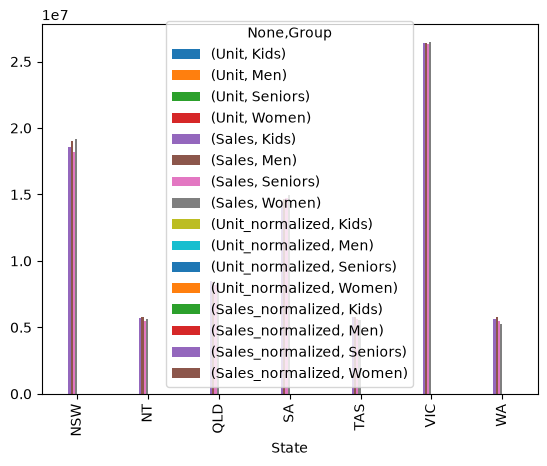

In [52]:
# state wise demographic sales with all categories with Stacked Bar Chart
data.groupby(['State', 'Group']).sum().unstack().plot(kind='bar', stacked=False)
# data.groupby(['State', 'Group'])['Sales'].sum().unstack().plot(kind='bar', stacked=True)

In [53]:
# witch time of the year sales are high and witch product using Line Chart and Countplot
import seaborn as sns
import matplotlib.pyplot as plt


In [54]:
print(data.info())
print(data.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              7560 non-null   str    
 1   Time              7560 non-null   str    
 2   State             7560 non-null   str    
 3   Group             7560 non-null   str    
 4   Unit              7560 non-null   int64  
 5   Sales             7560 non-null   int64  
 6   Unit_normalized   7560 non-null   float64
 7   Sales_normalized  7560 non-null   float64
dtypes: float64(2), int64(2), str(4)
memory usage: 472.6 KB
None
Date                    str
Time                    str
State                   str
Group                   str
Unit                  int64
Sales                 int64
Unit_normalized     float64
Sales_normalized    float64
dtype: object


In [55]:
data['Date'] = pd.to_datetime(data['Date'])

<Axes: xlabel='Date'>

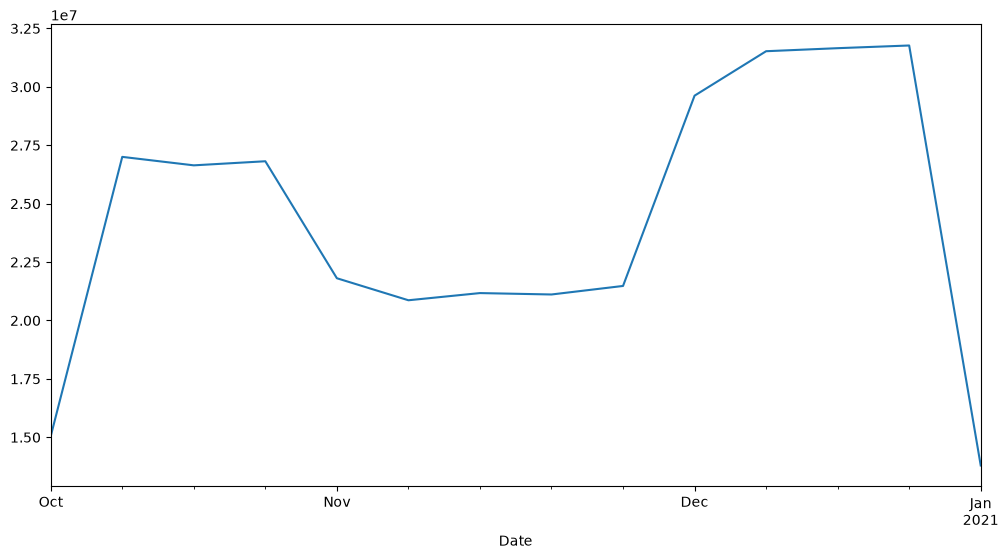

In [56]:
# week, Monthly, Quarterly reporting of sales data using line chart and countplot
weekly_sales = data.resample('W', on='Date')['Sales'].sum()
plt.figure(figsize=(12, 6))
weekly_sales.plot()

<Axes: xlabel='Date'>

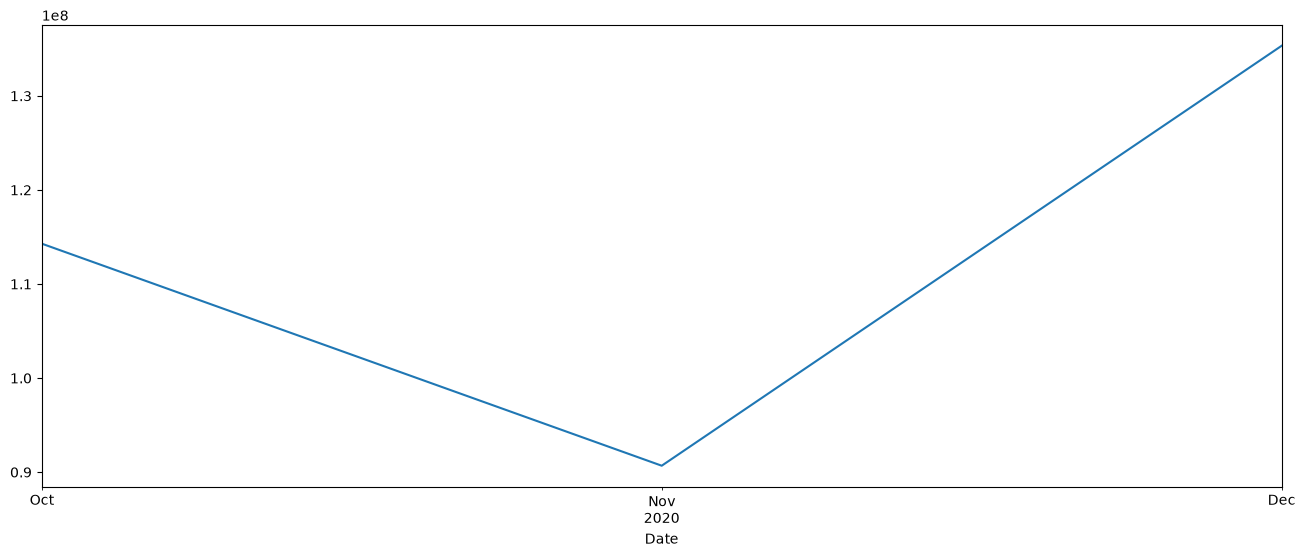

In [57]:
# time series analysis of sales data using line chart and countplot
monthly_sales = data.resample('ME', on='Date')['Sales'].sum()
plt.figure(figsize=(16, 6))
monthly_sales.plot()

c:\Users\UTL2397\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


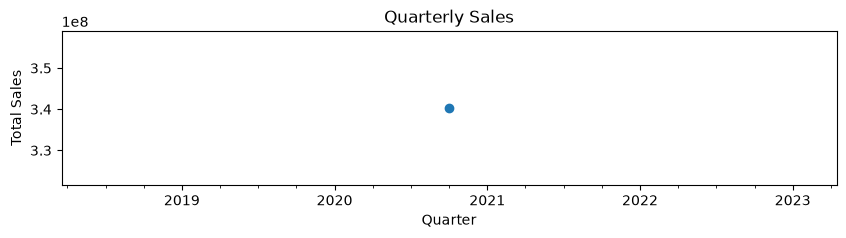

In [58]:
# Quarterly reporting of sales data using line chart and countplot 
data['Quarter'] = data['Date'].dt.to_period('Q')
plot_data = data.groupby('Quarter')['Sales'].sum()
plt.figure(figsize=(10, 2))
plot_data.plot(kind='line', marker='o')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.title('Quarterly Sales')
plt.show()

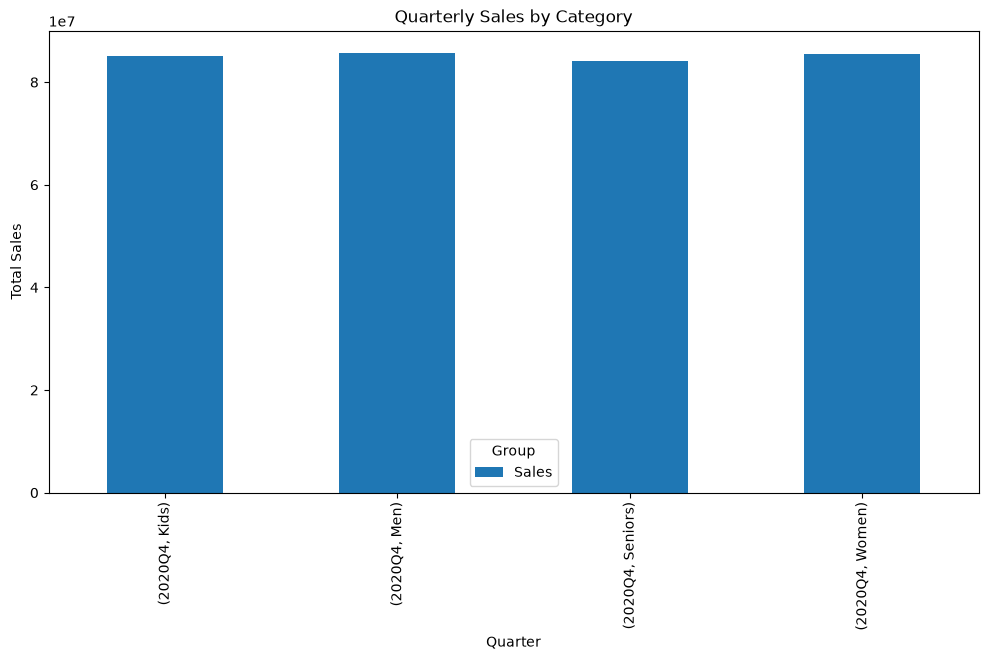

In [59]:
# Quarterly sales category wise (Group wise)
quarter_group_sales = data.groupby(['Quarter', 'Group'])['Sales'].sum()
quarter_group_sales.plot(kind='bar', figsize=(12, 6))
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.title('Quarterly Sales by Category')
plt.legend(title='Group')
plt.show()

Text(0.5, 0, 'State')

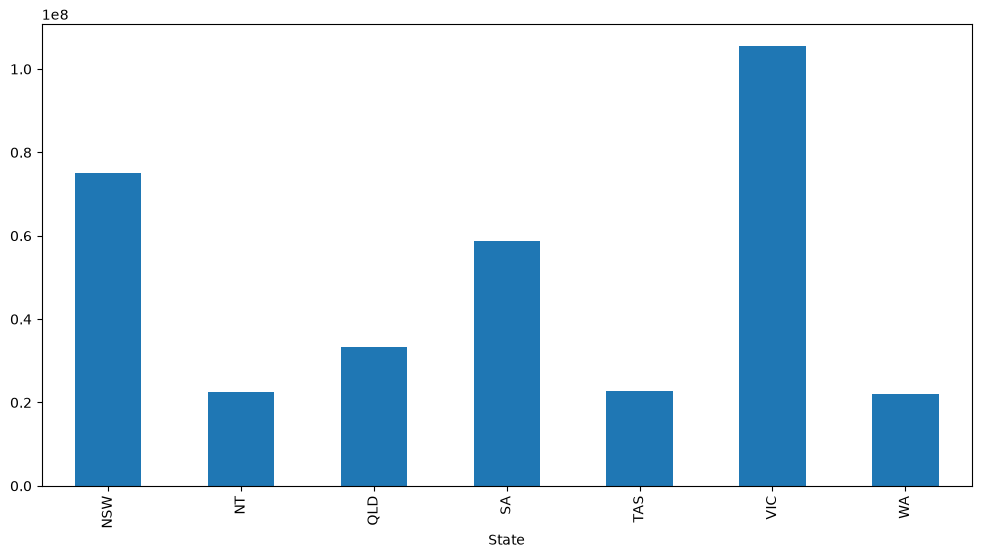

In [60]:
# comparing all state sales data using line chart and countplot
data.groupby('State')['Sales'].sum().plot(kind='bar', figsize=(12, 6))
plt.xlabel('State')

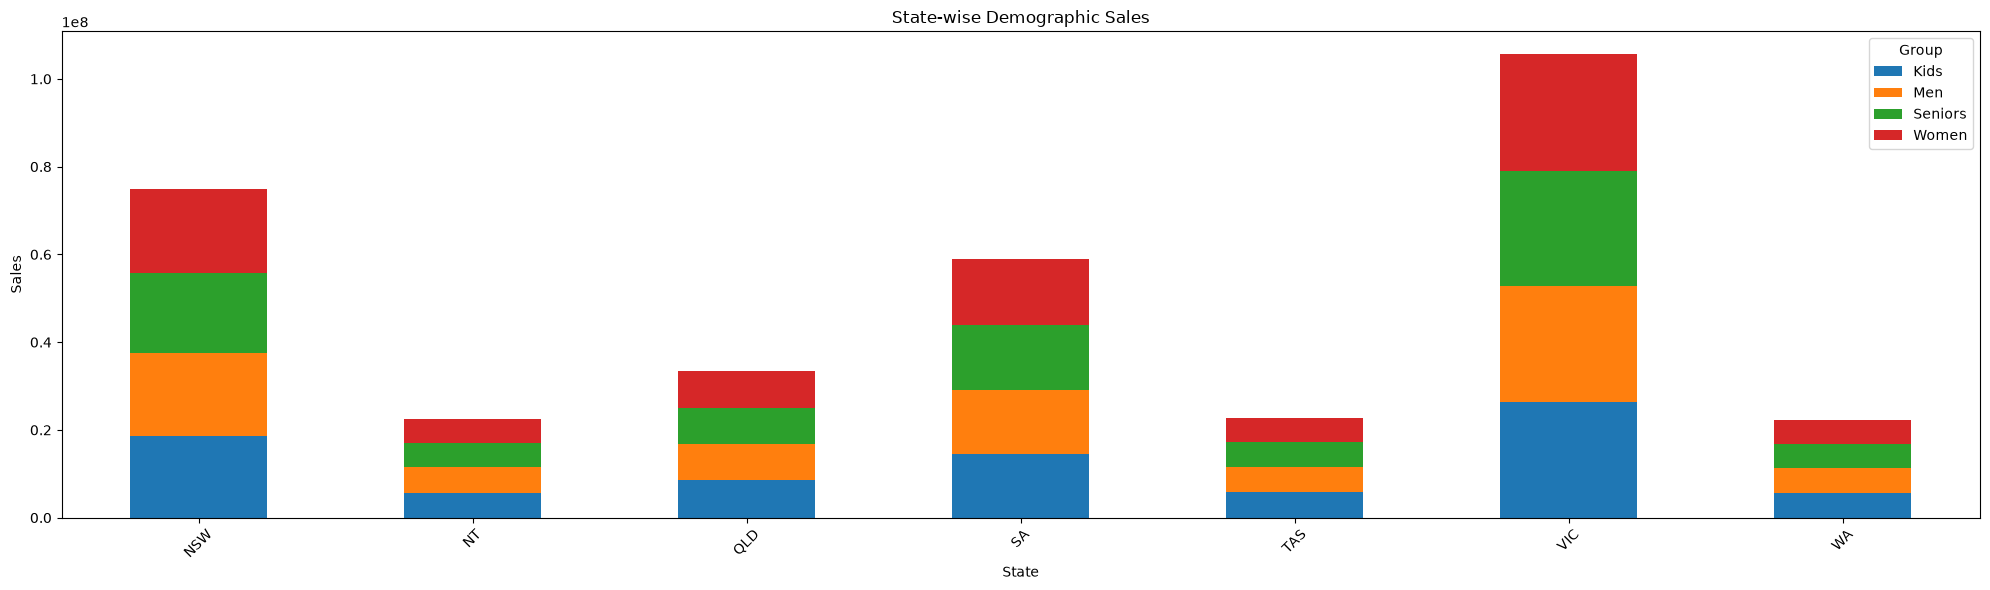

In [61]:
# State-wise Demographic Sales show sale state with All category wise ex Kids, Women, Men, Senior
# using stacked bar chart also using Grouped Bar Chart
data.groupby(['State', 'Group'])['Sales'].sum().unstack().plot(kind='bar', stacked=True, figsize=(20, 6))
plt.xlabel('State')
plt.ylabel('Sales')
plt.title('State-wise Demographic Sales')
plt.legend(title='Group')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Business Insights

- **Seasonality**: The dataset covers Q4 2020 only (Oct 1 - Dec 30). Monthly sales dipped in November (₹90.7M) after October (₹114.3M), then surged in December (₹135.3M) - a clear pre-Christmas/holiday buying spike.
- **State performance**: Sales are heavily concentrated in **VIC (₹105.6M)** and **NSW (₹75.0M)**, together accounting for over 60% of total sales. **WA, NT, and TAS** each contribute under ₹23M - the smallest markets.
- **Demographic groups**: Sales are fairly even across Men (₹85.75M), Women (₹85.44M), Kids (₹85.07M), and Seniors (₹84.04M) - no single group dominates, with only a ~2% spread between highest and lowest.
- **Time of day**: Morning (₹114.2M), Afternoon (₹114.0M), and Evening (₹112.1M) sales are nearly identical - time of day has minimal effect on total sales volume.
- **Distribution shape**: Sales is right-skewed (skewness ≈ 1.09) with moderate kurtosis (≈ 0.66), meaning most transactions are lower-value with a tail of high-value sales days/orders - visible in the box plot outliers and the distribution plot's long right tail.

# Recommendations

1. **Invest in November demand generation**: Run targeted promotions/discounts in November to smooth the seasonal dip between the October and December peaks.
2. **Prioritize VIC and NSW for premium/flagship campaigns** since they drive the majority of revenue, while treating WA, NT, and TAS as growth markets needing separate, smaller-scale strategies rather than a one-size-fits-all national campaign.
3. **No need to bias marketing spend by demographic group** - Kids, Men, Women, and Seniors contribute almost equally, so campaigns can stay broad rather than group-targeted.
4. **Time-of-day scheduling is low priority** - since Morning/Afternoon/Evening sales are nearly equal, staffing and ad-scheduling decisions should be driven by other factors (e.g. state-level time zones) rather than time-of-day demand differences.
5. **Investigate high-value outliers** flagged in the box plot - understanding what drives the largest sales days/transactions could reveal a repeatable bulk-order or promotional pattern worth scaling.
6. **Collect data beyond Q4** - a single quarter of data cannot support real quarter-over-quarter or year-over-year trend analysis; future reporting should include at least a full year to validate whether the Nov dip / Dec spike is a recurring seasonal pattern.

# Jupyter Notebook Report - Summary

**Dataset**: Australian Apparel Sales, Q4 2020 (7,560 rows; Date, Time, State, Group, Unit, Sales)

**Pipeline followed**:
Load CSV -> Inspect Data -> Clean Missing & Incorrect Values -> Normalize Data -> Descriptive Statistics -> GroupBy Analysis -> Weekly/Monthly/Quarterly Reports -> Visualizations (Bar, Line, Box Plot, Distribution Plot) -> Business Insights -> Recommendations -> this Report.

**Key numbers**:
- No missing values or negative sales found; leading/trailing whitespace in `Group`/`State`/`Time` was stripped as part of cleaning.
- `Unit` and `Sales` were min-max normalized to `Unit_normalized` / `Sales_normalized` for scale-independent comparison.
- Mean Sales = ₹45,013.56, Median = ₹35,000, right-skewed (skew ≈ 1.09).
- Total sales by month: Oct ₹114.3M -> Nov ₹90.7M -> Dec ₹135.3M.
- Total sales by state: VIC (₹105.6M) and NSW (₹75.0M) lead; WA/NT/TAS lag under ₹23M each.
- Total sales by group: Men, Women, Kids, Seniors are within ~2% of each other.

See the **Business Insights** and **Recommendations** sections above for the interpretation and suggested next steps.